<div style='background:#8B0000; padding:20px; border-radius:8px; margin-bottom:10px'>
<h1 style='color:white; text-align:center; margin:0'>Reconocimiento de Patrones</h1>
<h2 style='color:#ffcccc; text-align:center; margin:5px 0 0 0'>Challenge 7 — Redes Neuronales Convolucionales para Imágenes Biomédicas</h2>
<p style='color:#ffaaaa; text-align:center; margin:5px 0 0 0'>Ingeniería Biomédica · UPCH · 2026-1</p>
</div>

> **Nota para estudiantes:** las celdas con `TODO` indican exactamente qué deben completar. Las pistas orientan el razonamiento, pero no reemplazan la interpretación clínica.


## Contexto clínico

En el Challenge 6 entrenaste un **perceptrón** y un **MLP** usando variables tabulares del dataset Breast Cancer Wisconsin. Ahora pasamos de datos tabulares a **imágenes biomédicas**.

Trabajaremos con **PneumoniaMNIST**, un dataset de imágenes de radiografía de tórax en escala de grises, reducido a 28×28 píxeles, con dos clases:

- `0 = Normal`
- `1 = Pneumonia`

El objetivo será entrenar modelos en **PyTorch** para distinguir entre radiografías normales y radiografías con neumonía. Primero construiremos un **baseline MLP** que aplana la imagen y luego una **CNN** que conserva la estructura espacial.

**Pregunta clínica:** ¿por qué una CNN debería ser más adecuada que un MLP cuando la entrada es una imagen? ¿Qué error clínico es más crítico: clasificar una neumonía como normal o clasificar un caso normal como neumonía?

---
> **Dataset:** PneumoniaMNIST, colección MedMNIST.  
> Se descarga directamente desde Python usando la librería `medmnist`.


<div style='background:#e8f5e9; padding:8px 14px; border-left:4px solid #2e7d32; border-radius:4px; margin:8px 0'>
🧑‍🎓 <b>VERSIÓN ESTUDIANTE</b> — completa los espacios en blanco, ejecuta el notebook en orden y responde las preguntas de interpretación clínica.
</div>


---
## Ejercicio 1 — Diseño previo al código

### 1.1 — De MLP a CNN

<div style='background:#e8f5e9; padding:8px 14px; border-left:4px solid #2e7d32; border-radius:4px; margin:8px 0'>
⏱️ <b>EN CLASE</b> — responde antes de programar
</div>

**📝 Tu respuesta (edita esta celda):**

> **TODO:** responde con 2–3 líneas por pregunta. Usa conceptos de CNN, MLP y métricas clínicas.

**1. ¿Qué problema tiene usar un MLP directamente sobre una imagen?**  

Un MLP aplana el vector de una imagen a una única dimensión, destruyendo cualquier información espacia. Esto obliga al modelo a aprender relaciones de posición absoluta, lo cual requiere mucho más parámetros y no generaliza bien ante pequeños cambiso de imagen como traslaciones o rotaciones

---

**2. ¿Qué ventaja tiene una CNN?**  
Las CNN aplican filtros que permiten conservar los componentes espaciales de las imagenes. Además, los pesos de un mismo filtro se comparten en toda la imagen, lo que reduce drásticamente el número de parámetros y haciendo al modelo invariante a la posición de los patrones

---

**3. ¿Qué podría representar un filtro convolucional en una radiografía de tórax?**  
En capas iniciales podría representar los bordes, contornos de órganos o la transición entre tejido pulmonar y óseo. En capas profundas, la combinación del o anterior puede representar opacidades, consolidaciones, o patrones característicos de pataologías pulmonares


### 1.2 — Convolución, pooling y clasificación

<div style='background:#e8f5e9; padding:8px 14px; border-left:4px solid #2e7d32; border-radius:4px; margin:8px 0'>
⏱️ <b>EN CLASE</b> — responde con tus palabras
</div>

**📝 Tu respuesta (edita esta celda):**

> **TODO:** responde con 2–3 líneas por pregunta. Usa conceptos de CNN, MLP y métricas clínicas.

**1. ¿Qué produce una capa convolucional?**  
Produce una matriz 2D conocida como feature map, por cada filtro aprendido. Donde cada valor indica cuánto se activó un filtro en una posición en particular, de tal manera que N filtros permiten ob;tener N feature maps apilados

**2. ¿Para qué sirve MaxPooling?**  
Para reducir la resolución espacial de los feature maps, tomando el valro máximo dentro de una ventana. Esto con el fin de reducir el costo computacional, proporcionar invarianza local y/o ampliar el campo receptivo efectivo de las neuronas profundas

**3. ¿Por qué al final usamos una capa lineal?**  
Por que, al final, los feature map se aplanan en un vector. La última capa combina las representaciones aprendidas para producir el logit de clasificación para emitir una sola predicción por imagen.

**4. ¿Por qué seguimos usando `BCEWithLogitsLoss`?**  
Porque la tarea sigue siendo clasificación binaria (Normas vs Neumonía)

### 1.3 — Pipeline completo

**TODO:** completa cada paso del pipeline con una frase breve.

Completa el siguiente pipeline:

```text
PneumoniaMNIST
      │
      ▼
[ Paso A ] Descargar y dividir en splits train/val/test
      │
      ▼
[ Paso B ] Aplicar transformaciones: ToTensor + Normalize
      │
      ▼
[ Paso C ] Crear DataLoaders con mini-batches de 32
      │
      ▼
[ Paso D ] Definir arquitecturas del modelo MLP o CNN
      │
      ▼
[ Paso E ] Definir función de pérdida BCEWithLogitsLoss con pos_weight para desbalance
      │
      ▼
[ Paso F ] Loop de entrenamiento: forward -> loss -> zero_Grad -> backward -> step
      │
      ▼
[ Paso G ] Evaluar en val/test: calcular loss, accuracy, sensibilidad, especificidad, AUC
      │
      ▼
[ Paso H ] Analizar errores: Matrices de confusión, curva ROC y análisis de umbra
```

**📝 Pregunta:** ¿por qué conviene entrenar primero un MLP baseline antes de entrenar la CNN?  
El MLP establece una referencia, un baseline, pero sin la inducción de sesgo espacial. Si la CNN no supera al MLP en rendimiento, entonces hay un problema de implementación, bug o hiperparámetros, no de los datos. De esta manera podremos diagnosticar si la mejora proviene realmente de la arquitectura convulocional y no de otros factores


---
## Ejercicio 2 — Setup y carga de datos

<div style='background:#e8f5e9; padding:8px 14px; border-left:4px solid #2e7d32; border-radius:4px; margin:8px 0'>
⏱️ <b>EN CLASE</b> — completa esto durante la sesión
</div>

### Paso 2.1 — Librerías

In [1]:
# ── Instalación robusta de MedMNIST ─────────────────────────────
# En Google Colab debería ejecutarse sin problemas.
import importlib.util
import subprocess
import sys

if importlib.util.find_spec("medmnist") is None:
    subprocess.check_call([sys.executable, "-m", "pip", "install", "-q", "medmnist"])

# ── Colores institucionales UPCH ───────────────────────────────
UPCH_RED    = '#8B0000'
UPCH_BLUE   = '#1565C0'
UPCH_GREEN  = '#2E7D32'
UPCH_ORANGE = '#E65100'
UPCH_PURPLE = '#6A1B9A'
UPCH_GRAY   = '#4A4A4A'

# ── Librerías base ──────────────────────────────────────────────
import os
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# ── PyTorch ─────────────────────────────────────────────────────
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader
from torchvision import transforms

# ── Dataset MedMNIST ────────────────────────────────────────────
from medmnist import PneumoniaMNIST, INFO

# ── Métricas ────────────────────────────────────────────────────
from sklearn.metrics import (
    confusion_matrix, accuracy_score, precision_score, recall_score,
    f1_score, roc_auc_score, roc_curve
)

sns.set_context("notebook")
plt.rcParams['figure.figsize'] = (7, 4)

def seed_everything(seed=42):
    """Fija semillas para reproducibilidad."""
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)

seed_everything(42)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)

Device: cpu


### Paso 2.2 — Transformaciones y carga de PneumoniaMNIST

In [2]:
# ── Información del dataset ─────────────────────────────────────
info = INFO['pneumoniamnist']
print("Descripción:", info['description'][:300], "...")
print("Clases:", info['label'])
print("Canales:", info['n_channels'])

# ── Transformación: PIL/NumPy → Tensor normalizado ──────────────
# TODO 1: completa mean y std para una imagen en escala de grises.
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize(mean=(0.5,), std=(0.5,)) #Aproximación estándar
])

# ── Carga de splits oficiales ───────────────────────────────────
train_dataset = PneumoniaMNIST(split='train', transform=transform, download=True)
val_dataset   = PneumoniaMNIST(split='val',   transform=transform, download=True)
test_dataset  = PneumoniaMNIST(split='test',  transform=transform, download=True)

print(f"Train: {len(train_dataset)} imágenes")
print(f"Val:   {len(val_dataset)} imágenes")
print(f"Test:  {len(test_dataset)} imágenes")

sample_img, sample_label = train_dataset[0]
print("Forma de una imagen:", sample_img.shape)
print("Etiqueta ejemplo:", int(sample_label[0]))


Descripción: The PneumoniaMNIST is based on a prior dataset of 5,856 pediatric chest X-Ray images. The task is binary-class classification of pneumonia against normal. We split the source training set with a ratio of 9:1 into training and validation set and use its source validation set as the test set. The sour ...
Clases: {'0': 'normal', '1': 'pneumonia'}
Canales: 1


100%|██████████| 4.17M/4.17M [00:00<00:00, 4.57MB/s]


Train: 4708 imágenes
Val:   524 imágenes
Test:  624 imágenes
Forma de una imagen: torch.Size([1, 28, 28])
Etiqueta ejemplo: 1


### Paso 2.3 — Distribución de clases y visualización inicial

class_name,Normal,Pneumonia
split,,
test,234,390
train,1214,3494
val,135,389


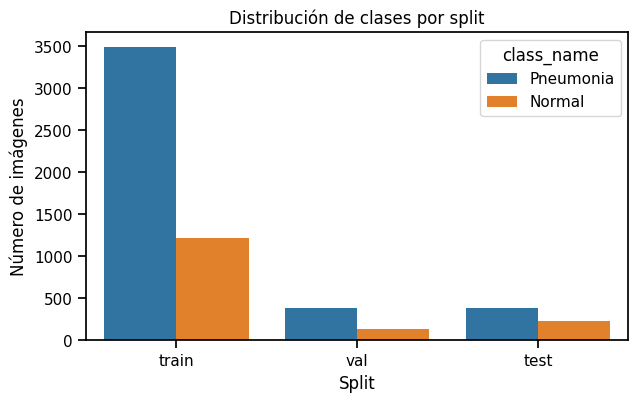

In [3]:
# ── Distribución de clases ──────────────────────────────────────
label_map = {0: "Normal", 1: "Pneumonia"}

def get_label_array(dataset):
    return dataset.labels.reshape(-1).astype(int)

train_labels = get_label_array(train_dataset)
val_labels   = get_label_array(val_dataset)
test_labels  = get_label_array(test_dataset)

dist_df = pd.DataFrame({
    "split": ["train"] * len(train_labels) + ["val"] * len(val_labels) + ["test"] * len(test_labels),
    "label": np.concatenate([train_labels, val_labels, test_labels])
})
dist_df["class_name"] = dist_df["label"].map(label_map)

display(pd.crosstab(dist_df["split"], dist_df["class_name"]))

fig, ax = plt.subplots(figsize=(7, 4))
sns.countplot(data=dist_df, x="split", hue="class_name", ax=ax)
ax.set_title("Distribución de clases por split")
ax.set_xlabel("Split")
ax.set_ylabel("Número de imágenes")
plt.show()

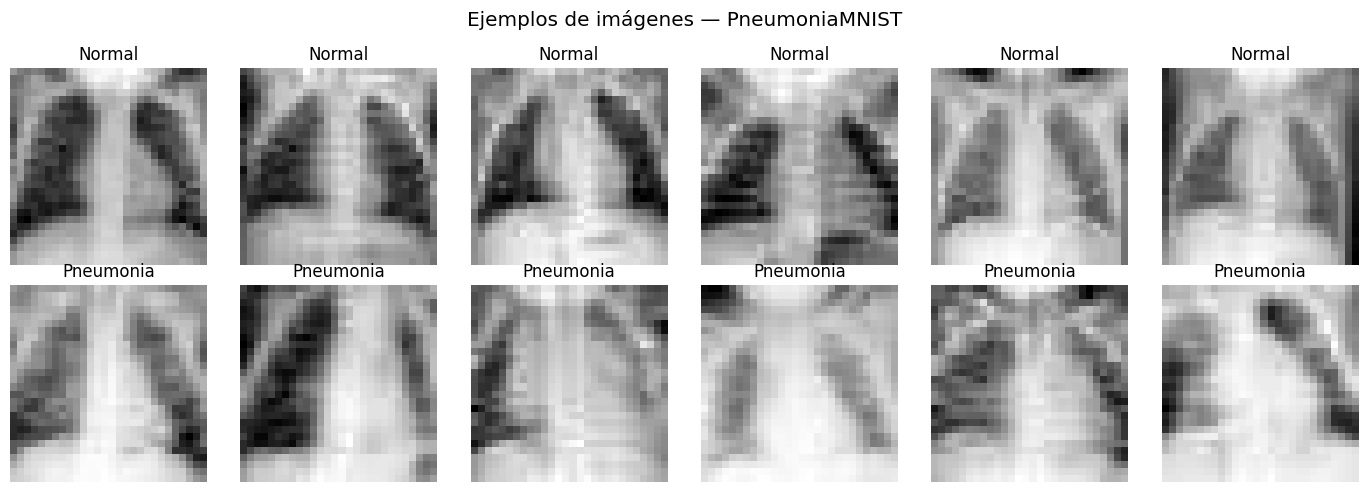

In [4]:
# ── Visualización de ejemplos ───────────────────────────────────
def unnormalize_img(img_tensor):
    """Convierte tensor normalizado [-1,1] a imagen [0,1] para visualizar."""
    return (img_tensor.squeeze().cpu().numpy() * 0.5) + 0.5

def plot_class_examples(dataset, n_per_class=6):
    labels = get_label_array(dataset)
    fig, axes = plt.subplots(2, n_per_class, figsize=(14, 5))

    for class_id in [0, 1]:
        idxs = np.where(labels == class_id)[0]
        chosen = np.random.choice(idxs, size=n_per_class, replace=False)

        for j, idx in enumerate(chosen):
            img, label = dataset[idx]
            axes[class_id, j].imshow(unnormalize_img(img), cmap="gray")
            axes[class_id, j].axis("off")
            axes[class_id, j].set_title(label_map[int(label[0])])

    plt.suptitle("Ejemplos de imágenes — PneumoniaMNIST")
    plt.tight_layout()
    plt.show()

plot_class_examples(train_dataset, n_per_class=6)

### Paso 2.4 — Interpretación inicial

**📝 Tu respuesta (edita esta celda):**

> **TODO:** responde con 2–3 líneas por pregunta. Usa conceptos de CNN, MLP y métricas clínicas.

**1. ¿Qué forma tiene cada imagen y qué significa cada dimensión?**
Cada imagen tiene una forma [1,28,28], donde el primer eje es el canal (escala de grises); mientras que los otros 2 corresponden a la altura y ancho en pixeles
___

**2. ¿Observas desbalance de clases? ¿Por qué importa?**
Sí, hay más imágenes de neuomnía que de casos normales. Es importante porque el desbalance afecta la función de pérdida y las métricas.
___

**3. En este problema, ¿qué sería un falso negativo?**  
Es cuando el sistema predice "Normal" cuando el paciente está enfermo.
___

**4. ¿Por qué una CNN puede ser apropiada para este tipo de dato?**  
Porque  los filtros convolucionales detectan las opacidades, infiltrados y consolidaciones que se suelen manifestar en radiografías de tórax en neumonía. Por lo que permite generalizar, en teoría, mejor que un MLP
___


---
# PARTE 1 — DataLoader y mini-batches de imágenes
## Ejercicio 3 — Preparación de mini-batches

<div style='background:#e8f5e9; padding:8px 14px; border-left:4px solid #2e7d32; border-radius:4px; margin:8px 0'>
⏱️ <b>EN CLASE</b> — completa esto durante la sesión
</div>

### Paso 3.1 — Creación de DataLoaders

In [5]:
# ── DataLoaders ─────────────────────────────────────────────────
# TODO 2: define un tamaño de mini-batch y el orden de mezcla.
BATCH_SIZE = 32

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True,  num_workers=0)
#No es necesario mezclar data que será usada únicamente para evaluar el algoritmo
val_loader   = DataLoader(val_dataset,   batch_size=BATCH_SIZE, shuffle=False, num_workers=0)
test_loader  = DataLoader(test_dataset,  batch_size=BATCH_SIZE, shuffle=False, num_workers=0)

xb, yb = next(iter(train_loader))

print("Mini-batch de imágenes:", xb.shape)
print("Mini-batch de etiquetas:", yb.shape)
print("Tipo de dato X:", xb.dtype)
print("Tipo de dato y:", yb.dtype)


Mini-batch de imágenes: torch.Size([32, 1, 28, 28])
Mini-batch de etiquetas: torch.Size([32, 1])
Tipo de dato X: torch.float32
Tipo de dato y: torch.int64


### Paso 3.2 — ¿Qué significa la forma del tensor?

In [6]:
# ── Interpretación de dimensiones ───────────────────────────────
# TODO 3: completa los prints usando las variables B, C, H y W.
B, C, H, W = xb.shape
print(f"B = {B} imágenes por mini-batch")
print(f"C = {C} canal(es) de imagen")
print(f"H = {H} píxeles de alto")
print(f"W = {W} píxeles de ancho")


B = 32 imágenes por mini-batch
C = 1 canal(es) de imagen
H = 28 píxeles de alto
W = 28 píxeles de ancho


### Paso 3.3 — Interpretación

**📝 Tu respuesta (edita esta celda):**

> **TODO:** responde con 2–3 líneas por pregunta. Usa conceptos de CNN, MLP y métricas clínicas.

**1. ¿Qué significa el formato `[batch, channels, height, width]`?**  
Es la convención estándar de PyTorch. El batch indica cuántas imágenes se procesan en paralelo; los channels indican cuántas capas de información tiene cada imagen; mientras que height y width indican las dimensiones espaciales de la imagen.
___

**2. ¿Por qué PneumoniaMNIST tiene un solo canal?**  
Por que los rayos X se expresan en una sola escala de intensidad (gris), no hay información de color como tal.
___

**3. ¿Por qué entrenamos con mini-batches en lugar de procesar todo el dataset de una sola vez?**  
Es inviable entrenar todo de golpe por temas de memoria. Al reducir esto en pequeños pasos, mini-batches, se puede actualizar con frecuencia los pesos con estimaciones ruidos, pero rápidas del grandietne real.
___


---
# PARTE 2 — Baseline MLP con imagen aplanada
## Ejercicio 4 — Modelo MLP para comparar contra CNN

<div style='background:#e8f5e9; padding:8px 14px; border-left:4px solid #2e7d32; border-radius:4px; margin:8px 0'>
⏱️ <b>EN CLASE</b> — completa esto durante la sesión
</div>

### Paso 4.1 — Definición del baseline MLP

In [7]:
# ── Baseline: MLP que aplana la imagen ──────────────────────────
# TODO 4: completa las dimensiones del MLP.
class FlattenMLP(nn.Module):
    def __init__(self):
        super().__init__()

        self.net = nn.Sequential(
            nn.Flatten(), #1*28*28 = 784 valores
            nn.Linear(784, 128),  # TODO 4.1: capa de entrada → capa oculta
            nn.ReLU(), #128 es un tamaño moderado
            nn.Linear(128,1)   # TODO 4.2: capa oculta → 1 logit
        )

    def forward(self, x):
        return self.net(x)

mlp_model = FlattenMLP().to(device)
print(mlp_model)


FlattenMLP(
  (net): Sequential(
    (0): Flatten(start_dim=1, end_dim=-1)
    (1): Linear(in_features=784, out_features=128, bias=True)
    (2): ReLU()
    (3): Linear(in_features=128, out_features=1, bias=True)
  )
)


### Paso 4.2 — Funciones generales de entrenamiento y evaluación

<div style='background:#e8f5e9; padding:8px 14px; border-left:4px solid #2e7d32; border-radius:4px; margin:8px 0'>
⏱️ <b>EN CLASE</b> — completa el cálculo de desbalance y el ciclo de entrenamiento
</div>

**Nota:** `pos_weight` ayuda a manejar desbalance en la función de pérdida, pero la decisión clínica final se analiza con sensibilidad, especificidad y umbrales.


In [9]:
# ── Conteo de parámetros ────────────────────────────────────────
def count_parameters(model):
    return sum(p.numel() for p in model.parameters() if p.requires_grad)

print("Parámetros del MLP:", count_parameters(mlp_model))

# ── Peso para clase positiva por desbalance ─────────────────────
# TODO 5: cuenta positivos y negativos usando train_labels.
# En este dataset: 0 = Normal, 1 = Pneumonia.
n_pos = (train_labels == 1).sum()
n_neg = (train_labels == 0).sum()
pos_weight = torch.tensor([n_neg / n_pos], dtype=torch.float32).to(device)

print(f"n_neg={n_neg}, n_pos={n_pos}, pos_weight={pos_weight.item():.3f}")

loss_fn = nn.BCEWithLogitsLoss(pos_weight=pos_weight)

def train_one_epoch(model, loader, loss_fn, optimizer, device):
    model.train()

    total_loss = 0.0
    correct = 0
    n = 0

    for X_batch, y_batch in loader:
        X_batch = X_batch.to(device)
        y_batch = y_batch.float().view(-1, 1).to(device)

        # TODO 6: forward pass → pérdida → backpropagation → actualización
        logits = model(X_batch)
        loss = loss_fn(logits, y_batch)

        optimizer.zero_grad() #Limpiar gradientes acumulados
        loss.backward() #Gradientes
        optimizer.step() #Actualizar pesos Adam

        total_loss += loss.item() * X_batch.size(0)

        probs = torch.sigmoid(logits)
        preds = (probs >= 0.5).float()
        correct += (preds == y_batch).sum().item()
        n += X_batch.size(0)

    return total_loss / n, correct / n


@torch.no_grad()
def evaluate_one_epoch(model, loader, loss_fn, device):
    model.eval()

    total_loss = 0.0
    correct = 0
    n = 0

    for X_batch, y_batch in loader:
        X_batch = X_batch.to(device)
        y_batch = y_batch.float().view(-1, 1).to(device)

        logits = model(X_batch)
        loss = loss_fn(logits, y_batch)

        total_loss += loss.item() * X_batch.size(0)

        probs = torch.sigmoid(logits)
        preds = (probs >= 0.5).float()
        correct += (preds == y_batch).sum().item()
        n += X_batch.size(0)

    return total_loss / n, correct / n


def fit_model(model, train_loader, val_loader, loss_fn, optimizer, device, epochs=6):
    history = {
        "train_loss": [], "val_loss": [],
        "train_acc": [],  "val_acc": []
    }

    for epoch in range(1, epochs + 1):
        train_loss, train_acc = train_one_epoch(model, train_loader, loss_fn, optimizer, device)
        val_loss, val_acc     = evaluate_one_epoch(model, val_loader, loss_fn, device)

        history["train_loss"].append(train_loss)
        history["val_loss"].append(val_loss)
        history["train_acc"].append(train_acc)
        history["val_acc"].append(val_acc)

        print(
            f"Epoch {epoch:02d}/{epochs} | "
            f"train_loss={train_loss:.4f} | val_loss={val_loss:.4f} | "
            f"train_acc={train_acc:.3f} | val_acc={val_acc:.3f}"
        )

    return history


def plot_history(history, title):
    fig, axes = plt.subplots(1, 2, figsize=(12, 4))

    axes[0].plot(history["train_loss"], marker="o", label="train")
    axes[0].plot(history["val_loss"], marker="o", label="val")
    axes[0].set_title(f"{title} — Loss")
    axes[0].set_xlabel("Época")
    axes[0].set_ylabel("Loss")
    axes[0].legend()

    axes[1].plot(history["train_acc"], marker="o", label="train")
    axes[1].plot(history["val_acc"], marker="o", label="val")
    axes[1].set_title(f"{title} — Accuracy")
    axes[1].set_xlabel("Época")
    axes[1].set_ylabel("Accuracy")
    axes[1].legend()

    plt.tight_layout()
    plt.show()


Parámetros del MLP: 100609
n_neg=1214, n_pos=3494, pos_weight=0.347


### Paso 4.3 — Entrenamiento del MLP

Epoch 01/20 | train_loss=0.1097 | val_loss=0.0808 | train_acc=0.912 | val_acc=0.929
Epoch 02/20 | train_loss=0.0691 | val_loss=0.0735 | train_acc=0.948 | val_acc=0.947
Epoch 03/20 | train_loss=0.0645 | val_loss=0.0677 | train_acc=0.954 | val_acc=0.952
Epoch 04/20 | train_loss=0.0601 | val_loss=0.0616 | train_acc=0.955 | val_acc=0.948
Epoch 05/20 | train_loss=0.0556 | val_loss=0.0700 | train_acc=0.958 | val_acc=0.937
Epoch 06/20 | train_loss=0.0554 | val_loss=0.0694 | train_acc=0.958 | val_acc=0.952
Epoch 07/20 | train_loss=0.0493 | val_loss=0.0589 | train_acc=0.963 | val_acc=0.952
Epoch 08/20 | train_loss=0.0444 | val_loss=0.0713 | train_acc=0.966 | val_acc=0.931
Epoch 09/20 | train_loss=0.0521 | val_loss=0.0670 | train_acc=0.961 | val_acc=0.954
Epoch 10/20 | train_loss=0.0392 | val_loss=0.0695 | train_acc=0.971 | val_acc=0.954
Epoch 11/20 | train_loss=0.0385 | val_loss=0.0720 | train_acc=0.970 | val_acc=0.950
Epoch 12/20 | train_loss=0.0360 | val_loss=0.0634 | train_acc=0.973 | val_ac

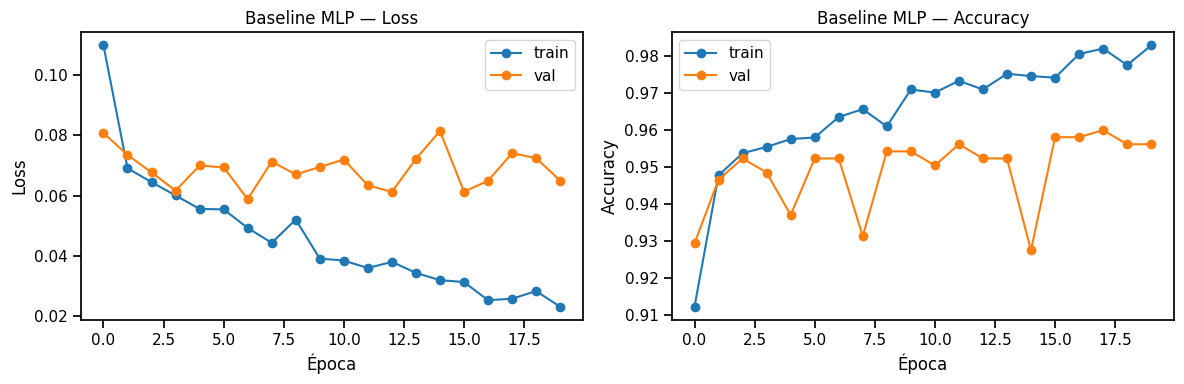

In [19]:
# ── Entrenamiento del baseline MLP ──────────────────────────────
# TODO 7: define learning rate y número de épocas.
#         Pista: empieza con lr=1e-3 y pocas épocas para que sea rápido en clase.
seed_everything(42)

mlp_model = FlattenMLP().to(device)
mlp_optimizer = optim.Adam(mlp_model.parameters(), lr=1e-3) #Default de Adam

mlp_history = fit_model(
    model=mlp_model,
    train_loader=train_loader,
    val_loader=val_loader,
    loss_fn=loss_fn,
    optimizer=mlp_optimizer,
    device=device,
    epochs=20 #Debería ser suficiente para observar convergencia
)

plot_history(mlp_history, "Baseline MLP")


### Paso 4.4 — Interpretación del baseline

**📝 Tu respuesta (edita esta celda):**

> **TODO:** responde con 2–3 líneas por pregunta. Usa conceptos de CNN, MLP y métricas clínicas.

**1. ¿Qué información espacial pierde el MLP al aplanar la imagen?**  
Se pierde por completo la relación de vecindad entre píxeles. Esto elimina la posibilidad de detectar contornos, texturas o formas locales esenciales para identificar infiltrados pulmonares
___

**2. ¿Por qué este MLP sirve como baseline y no necesariamente como mejor modelo final?**  
El MLP establece qué accuracy/AUC se puede alcanzar ignorando la estructura espacial. Si la CNN no lo supera, la CNN está mal implementada o los hiperparámetros son inadecuados. En imágenes, una CNN bien diseñada debe superar al MLP, especialmente en sensibilidad y AUC
___


---
# PARTE 3 — CNN para clasificación de radiografías
## Ejercicio 5 — Modelo convolucional en PyTorch

<div style='background:#fff3e0; padding:8px 14px; border-left:4px solid #e65100; border-radius:4px; margin:8px 0'>
📚 <b>TAREA</b> — completa esto antes de la siguiente clase
</div>

### Paso 5.1 — Definición de la CNN

In [12]:
# ── CNN simple para imágenes 28×28 en escala de grises ──────────
# TODO 8: completa la arquitectura CNN.
class SimpleCNN(nn.Module):
    def __init__(self):
        super().__init__()

        self.features = nn.Sequential(
            nn.Conv2d(in_channels=1, out_channels=16, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2),   # [B, 16, 28, 28] → [B, 16, 14, 14]

            # Bloque convolucional 2
            nn.Conv2d(in_channels=16, out_channels=32, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2)    # [B, 32, 14, 14] → [B, 32, 7, 7]
        )

        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(32*7*7, 64),  # TODO 8.5: flatten features → capa oculta
            nn.ReLU(),
            nn.Linear(64, 1)  # TODO 8.6: capa oculta → 1 logit
        )

    def forward(self, x):
        x = self.features(x)
        x = self.classifier(x)
        return x

cnn_model = SimpleCNN().to(device)
print(cnn_model)
print("Parámetros de la CNN:", count_parameters(cnn_model))


SimpleCNN(
  (features): Sequential(
    (0): Conv2d(1, 16, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU()
    (2): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (3): Conv2d(16, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (4): ReLU()
    (5): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (classifier): Sequential(
    (0): Flatten(start_dim=1, end_dim=-1)
    (1): Linear(in_features=1568, out_features=64, bias=True)
    (2): ReLU()
    (3): Linear(in_features=64, out_features=1, bias=True)
  )
)
Parámetros de la CNN: 105281


### Paso 5.2 — Verificación de dimensiones con un mini-batch

In [20]:
# ── Sanity check de dimensiones ─────────────────────────────────
# TODO 9: pasa el mismo mini-batch por extractor de características y modelo completo.
xb, yb = next(iter(train_loader))
xb = xb.to(device)

with torch.no_grad():
    feature_maps = cnn_model.features(xb)  # salida del extractor conv
    logits = cnn_model(xb)                  # salida completa del modelo

print("Entrada:", xb.shape)
print("Después de convoluciones + pooling:", feature_maps.shape)
print("Salida logits:", logits.shape)


Entrada: torch.Size([32, 1, 28, 28])
Después de convoluciones + pooling: torch.Size([32, 32, 7, 7])
Salida logits: torch.Size([32, 1])


### Paso 5.3 — Entrenamiento de la CNN

Epoch 01/20 | train_loss=0.1402 | val_loss=0.0953 | train_acc=0.883 | val_acc=0.956
Epoch 02/20 | train_loss=0.0830 | val_loss=0.0731 | train_acc=0.936 | val_acc=0.933
Epoch 03/20 | train_loss=0.0667 | val_loss=0.0873 | train_acc=0.952 | val_acc=0.958
Epoch 04/20 | train_loss=0.0612 | val_loss=0.0654 | train_acc=0.953 | val_acc=0.958
Epoch 05/20 | train_loss=0.0556 | val_loss=0.0577 | train_acc=0.957 | val_acc=0.954
Epoch 06/20 | train_loss=0.0483 | val_loss=0.0529 | train_acc=0.965 | val_acc=0.950
Epoch 07/20 | train_loss=0.0444 | val_loss=0.0576 | train_acc=0.966 | val_acc=0.960
Epoch 08/20 | train_loss=0.0403 | val_loss=0.0527 | train_acc=0.970 | val_acc=0.962
Epoch 09/20 | train_loss=0.0381 | val_loss=0.0690 | train_acc=0.971 | val_acc=0.962
Epoch 10/20 | train_loss=0.0365 | val_loss=0.1220 | train_acc=0.974 | val_acc=0.958
Epoch 11/20 | train_loss=0.0351 | val_loss=0.0728 | train_acc=0.972 | val_acc=0.962
Epoch 12/20 | train_loss=0.0314 | val_loss=0.0551 | train_acc=0.978 | val_ac

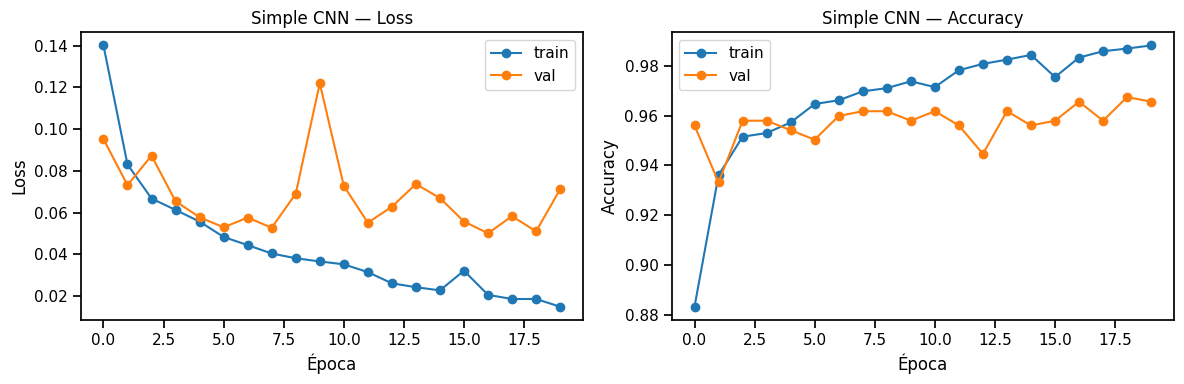

In [21]:
# ── Entrenamiento de la CNN ─────────────────────────────────────
# TODO 10: define learning rate y épocas para la CNN.
seed_everything(42)

cnn_model = SimpleCNN().to(device)
cnn_optimizer = optim.Adam(cnn_model.parameters(), lr=1e-3)

cnn_history = fit_model(
    model=cnn_model,
    train_loader=train_loader,
    val_loader=val_loader,
    loss_fn=loss_fn,
    optimizer=cnn_optimizer,
    device=device,
    epochs=20
)

plot_history(cnn_history, "Simple CNN")


### Paso 5.4 — Comparación visual de curvas

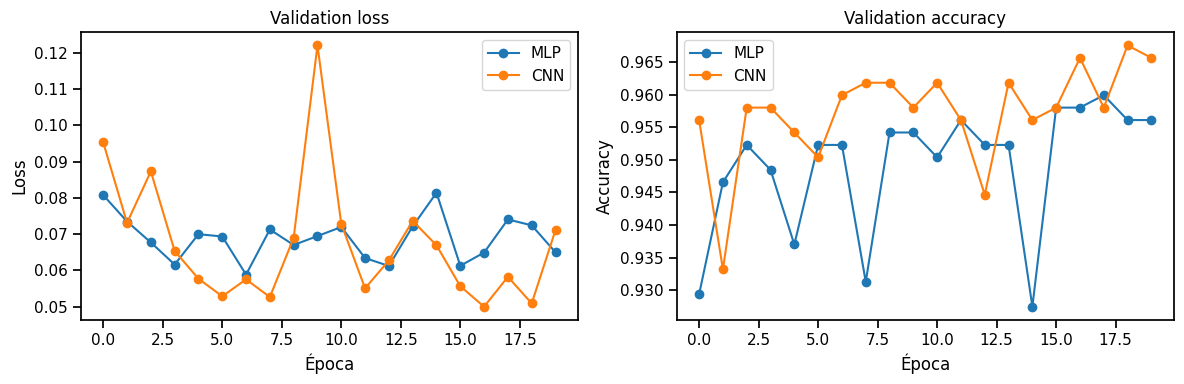

In [28]:
# ── Comparación de curvas MLP vs CNN ────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].plot(mlp_history["val_loss"], marker="o", label="MLP")
axes[0].plot(cnn_history["val_loss"], marker="o", label="CNN")
axes[0].set_title("Validation loss")
axes[0].set_xlabel("Época")
axes[0].set_ylabel("Loss")
axes[0].legend()

axes[1].plot(mlp_history["val_acc"], marker="o", label="MLP")
axes[1].plot(cnn_history["val_acc"], marker="o", label="CNN")
axes[1].set_title("Validation accuracy")
axes[1].set_xlabel("Época")
axes[1].set_ylabel("Accuracy")
axes[1].legend()

plt.tight_layout()
plt.show()

### Paso 5.5 — Interpretación CNN vs MLP

**📝 Tu respuesta (edita esta celda):**

> **TODO:** responde con 2–3 líneas por pregunta. Usa conceptos de CNN, MLP y métricas clínicas.

**1. ¿La CNN mejora frente al MLP? Usa tus curvas y métricas, no solo accuracy.**  
En general sí: la CNN muestra menor val_loss y mayor val_acc que el MLP al final del entrenamiento, y en la evaluación. Aunque la diferencia no sea demasiada y existan pico considerables
___

**2. ¿Qué aporta la convolución que no aporta el MLP al aplanar la imagen?**  
Inducción de sesgo espacial que son invariantes a la posición.  El *weight sharing* reduce los parámetros y fuerza al modelo a aprender representaciones que funcionan en cualquier región del pulmón, no solo en una posición fija del vector aplanado
___

**3. Si la CNN tiene mejor AUC o especificidad, pero menor sensibilidad con umbral 0.5, ¿cómo interpretarías ese resultado?**  
Significa que la CNN tiene mejor discriminación global (AUC) pero está siendo conservadora con el umbral por defecto. La solución clínica es bajar el umbral a 0.3–0.4 para priorizar sensibilidad, aceptando más falsos positivos que pueden filtrarse con confirmación médica
___

**4. ¿Qué factores podrían explicar que una CNN simple no mejore mucho frente al baseline?**  
Primero, las imágenes son muy pequeñas (28×28): a esa resolución se pierde mucho detalle clínico y el MLP tiene menos desventaja. Segundo, la CNN aquí es muy superficial (2 bloques); podría beneficiarse de más capas o dropout. Tercero, el dataset de entrenamiento es relativamente pequeño para deep learning; con augmentación de datos (rotaciones, flips) la CNN se beneficiaría más que el MLP.
___


---
# PARTE 4 — Métricas clínicas y análisis de errores
## Ejercicio 6 — Evaluación final

<div style='background:#fff3e0; padding:8px 14px; border-left:4px solid #e65100; border-radius:4px; margin:8px 0'>
📚 <b>TAREA</b> — completa esto antes de la siguiente clase
</div>

### Paso 6.1 — Predicción de probabilidades

In [22]:
# ── Predicción de probabilidades en test ────────────────────────
# TODO 11: convierte logits en probabilidades con sigmoid.
@torch.no_grad()
def predict_proba(model, loader, device):
    model.eval()

    all_probs = []
    all_true = []

    for X_batch, y_batch in loader:
        X_batch = X_batch.to(device)
        logits = model(X_batch)
        probs = torch.sigmoid(logits)

        all_probs.extend(probs)
        all_true.extend(y_batch.numpy().reshape(-1).astype(int))

    return np.array(all_true), np.array(all_probs)

y_test_true, mlp_prob = predict_proba(mlp_model, test_loader, device)
_, cnn_prob = predict_proba(cnn_model, test_loader, device)

print("Primeras probabilidades MLP:", mlp_prob[:5])
print("Primeras probabilidades CNN:", cnn_prob[:5])


Primeras probabilidades MLP: [[9.9999976e-01]
 [9.9999881e-01]
 [9.9581414e-01]
 [3.2010596e-04]
 [9.9997330e-01]]
Primeras probabilidades CNN: [[9.9999964e-01]
 [9.9999321e-01]
 [9.9884748e-01]
 [7.6353735e-06]
 [9.9999988e-01]]


### Paso 6.2 — Métricas clínicas

In [23]:
# ── Métricas clínicas ───────────────────────────────────────────
# TODO 12: completa sensibilidad, especificidad y precisión.
def clinical_metrics(y_true, y_prob, threshold=0.5, model_name="model"):
    y_pred = (y_prob >= threshold).astype(int)

    tn, fp, fn, tp = confusion_matrix(y_true, y_pred, labels=[0, 1]).ravel()

    # Sensibilidad = TP / (TP + FN)
    sensitivity = tp / (tp + fn) if (tp + fn) > 0 else np.nan
    # Especificidad = TN / (TN + FP)
    specificity = tn / (tn + fp) if (tn + fp) > 0 else np.nan
    # Precisión = TP / (TP + FP)
    precision   = tp / (tp + fp) if (tp + fp) > 0 else np.nan

    return {
        "model": model_name,
        "threshold": threshold,
        "accuracy": accuracy_score(y_true, y_pred),
        "sensitivity_recall": sensitivity,
        "specificity": specificity,
        "precision": precision,
        "f1": f1_score(y_true, y_pred),
        "roc_auc": roc_auc_score(y_true, y_prob),
        "TN": tn, "FP": fp, "FN": fn, "TP": tp
    }

results = pd.DataFrame([
    clinical_metrics(y_test_true, mlp_prob, threshold=0.5, model_name="MLP"),
    clinical_metrics(y_test_true, cnn_prob, threshold=0.5, model_name="CNN")
])

display(results)


,model,threshold,accuracy,sensitivity_recall,specificity,precision,f1,roc_auc,TN,FP,FN,TP
0,MLP,0.5,0.870192,0.979487,0.688034,0.839560,0.904142,0.935936,161,73,8,382
1,CNN,0.5,0.862179,0.994872,0.641026,0.822034,0.900232,0.941004,150,84,2,388


### Paso 6.3 — Matrices de confusión

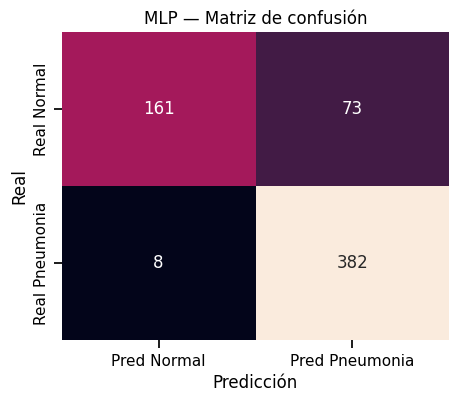

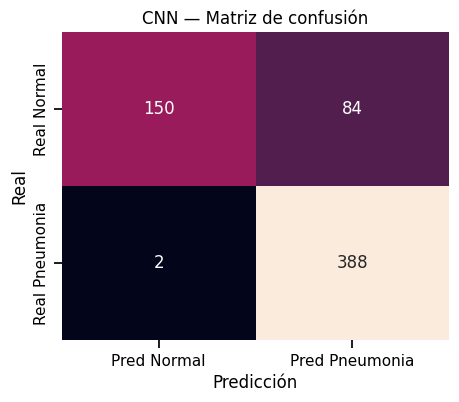

In [24]:
# ── Matrices de confusión ───────────────────────────────────────
def plot_confusion(y_true, y_prob, threshold, title):
    y_pred = (y_prob >= threshold).astype(int)
    cm = confusion_matrix(y_true, y_pred, labels=[0, 1])

    fig, ax = plt.subplots(figsize=(5, 4))
    sns.heatmap(
        cm, annot=True, fmt="d", cbar=False,
        xticklabels=["Pred Normal", "Pred Pneumonia"],
        yticklabels=["Real Normal", "Real Pneumonia"],
        ax=ax
    )
    ax.set_title(title)
    ax.set_xlabel("Predicción")
    ax.set_ylabel("Real")
    plt.show()

plot_confusion(y_test_true, mlp_prob, threshold=0.5, title="MLP — Matriz de confusión")
plot_confusion(y_test_true, cnn_prob, threshold=0.5, title="CNN — Matriz de confusión")

### Paso 6.4 — Curva ROC

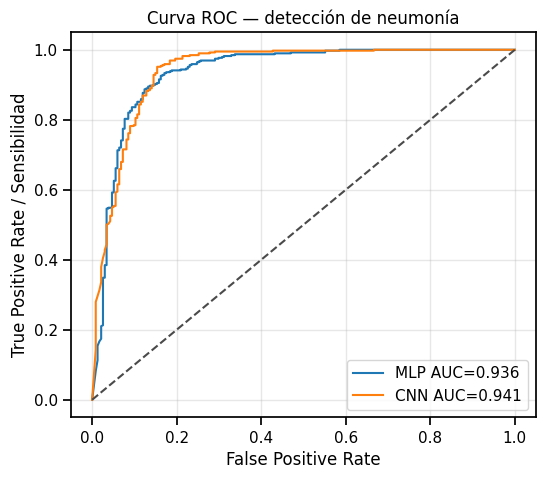

In [25]:
# ── Curva ROC ───────────────────────────────────────────────────
fpr_mlp, tpr_mlp, _ = roc_curve(y_test_true, mlp_prob)
fpr_cnn, tpr_cnn, _ = roc_curve(y_test_true, cnn_prob)

auc_mlp = roc_auc_score(y_test_true, mlp_prob)
auc_cnn = roc_auc_score(y_test_true, cnn_prob)

fig, ax = plt.subplots(figsize=(6, 5))
ax.plot(fpr_mlp, tpr_mlp, label=f"MLP AUC={auc_mlp:.3f}")
ax.plot(fpr_cnn, tpr_cnn, label=f"CNN AUC={auc_cnn:.3f}")
ax.plot([0, 1], [0, 1], "--", color=UPCH_GRAY)
ax.set_title("Curva ROC — detección de neumonía")
ax.set_xlabel("False Positive Rate")
ax.set_ylabel("True Positive Rate / Sensibilidad")
ax.legend()
ax.grid(alpha=0.3)
plt.show()

### Paso 6.5 — Análisis de umbral para la CNN

Un modelo produce probabilidades, pero la etiqueta final depende del **umbral de decisión**. En problemas clínicos, este umbral no siempre debe ser 0.5.

**Pregunta guía:** si el objetivo clínico es reducir falsos negativos, ¿qué umbral recomendarías y qué costo tendría en falsos positivos?


In [29]:
# ── Análisis de umbral ──────────────────────────────────────────
# TODO 13: prueba tres umbrales: bajo, estándar y alto.
threshold_rows = []
for th in [0.3, 0.5, 0.7]:
    threshold_rows.append(
        clinical_metrics(y_test_true, cnn_prob, threshold=th, model_name="CNN")
    )

threshold_df = pd.DataFrame(threshold_rows)
display(threshold_df[[
    "model", "threshold", "accuracy", "sensitivity_recall",
    "specificity", "precision", "f1", "FN", "FP", "TP", "TN"
]])


,model,threshold,accuracy,sensitivity_recall,specificity,precision,f1,FN,FP,TP,TN
0,CNN,0.3,0.841346,0.994872,0.585470,0.800000,0.886857,2,97,388,137
1,CNN,0.5,0.862179,0.994872,0.641026,0.822034,0.900232,2,84,388,150
2,CNN,0.7,0.881410,0.994872,0.692308,0.843478,0.912941,2,72,388,162


### Paso 6.6 — Visualización de errores

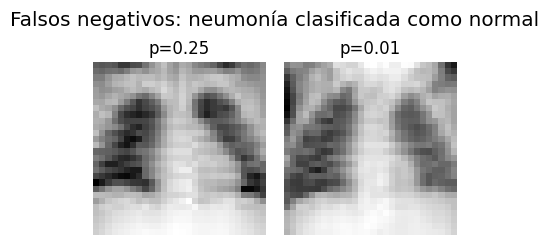

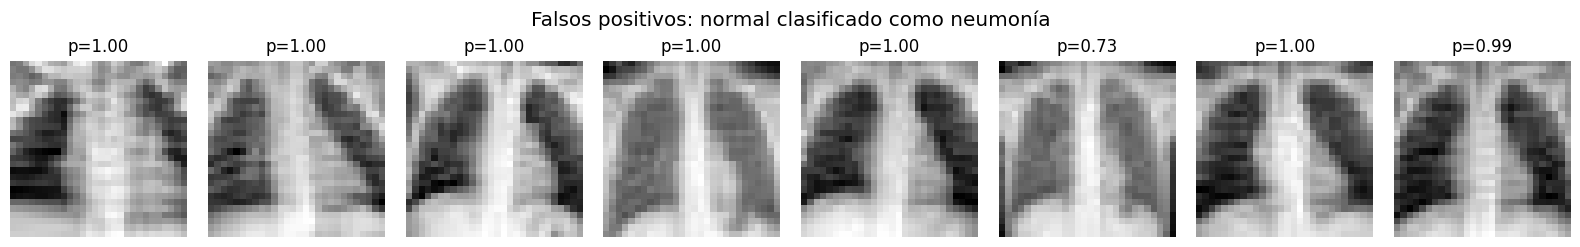

In [27]:
# ── Visualización de falsos negativos y falsos positivos ────────
@torch.no_grad()
def collect_images_probs(model, loader, device):
    model.eval()

    images = []
    y_true = []
    y_prob = []

    for X_batch, y_batch in loader:
        logits = model(X_batch.to(device))
        probs = torch.sigmoid(logits).cpu().numpy().reshape(-1)

        images.append(X_batch.cpu())
        y_true.extend(y_batch.numpy().reshape(-1).astype(int))
        y_prob.extend(probs)

    images = torch.cat(images, dim=0)
    return images, np.array(y_true), np.array(y_prob)


def plot_errors(model, loader, device, error_type="FN", threshold=0.5, max_images=8):
    images, y_true, y_prob = collect_images_probs(model, loader, device)
    y_pred = (y_prob >= threshold).astype(int)

    if error_type == "FN":
        idxs = np.where((y_true == 1) & (y_pred == 0))[0]
        title = "Falsos negativos: neumonía clasificada como normal"
    elif error_type == "FP":
        idxs = np.where((y_true == 0) & (y_pred == 1))[0]
        title = "Falsos positivos: normal clasificado como neumonía"
    else:
        raise ValueError("error_type debe ser 'FN' o 'FP'")

    if len(idxs) == 0:
        print(f"No se encontraron errores tipo {error_type} con threshold={threshold}.")
        return

    chosen = idxs[:max_images]

    fig, axes = plt.subplots(1, len(chosen), figsize=(2 * len(chosen), 2.5))
    if len(chosen) == 1:
        axes = [axes]

    for ax, idx in zip(axes, chosen):
        ax.imshow(unnormalize_img(images[idx]), cmap="gray")
        ax.axis("off")
        ax.set_title(f"p={y_prob[idx]:.2f}")

    plt.suptitle(title)
    plt.tight_layout()
    plt.show()

plot_errors(cnn_model, test_loader, device, error_type="FN", threshold=0.5, max_images=8)
plot_errors(cnn_model, test_loader, device, error_type="FP", threshold=0.5, max_images=8)

### Paso 6.7 — Interpretación final

**📝 Tu respuesta (edita esta celda):**

> **TODO:** responde con 2–3 líneas por pregunta. Usa conceptos de CNN, MLP y métricas clínicas.

**1. ¿Qué modelo elegirías como apoyo diagnóstico: MLP o CNN? Justifica con métricas.**  
La CNN, aunque su AUC es ligeramente superior al MLP, la CNN presenta menor cantidad de Falsos negativos con respecto al MLP
___

**2. ¿Qué métrica priorizarías si quieres reducir neumonías no detectadas?**  
La sensibilidad. Un modelo con sensibilidad de 0.95 deja pasar solo el 5% de las neumonías reales. El F1 también es útil pero no aísla los FN como lo hace la sensibilidad
___

**3. ¿Qué pasa con falsos positivos y falsos negativos al bajar el umbral?**  
La sensibilidad no se ve afectada, pero el resto de parámetros mejoran , por lo que se reducen los falsos positivos pero se mantienen los falsos negativos
___

**4. ¿Qué umbral recomendarías para la CNN si el objetivo es reducir falsos negativos? Justifica con la tabla.**
0.7. Si bien la sensibilidad, los falsos negativos, no cambian en la tabla, el resto de parámetros se ven mejorados.
___

**5. ¿Por qué este modelo no debe interpretarse como reemplazo del médico?**  
Por que el modelo aprende correlaciones estadísticas en 28×28 píxeles de baja resolución, sin contexto clínico. Es una herramienta de soporte, no de reemplazo.
___


## Checklist de entrega

Antes de entregar, verifica que tu notebook incluya:

- [ ] Respuestas conceptuales completas sobre MLP vs CNN, convolución, pooling y clasificación binaria.
- [ ] Carga correcta de PneumoniaMNIST con splits train/validation/test.
- [ ] Visualización de ejemplos de ambas clases.
- [ ] Creación correcta de DataLoaders con mini-batches.
- [ ] Definición funcional de `FlattenMLP`.
- [ ] Definición funcional de `SimpleCNN`.
- [ ] Loop explícito de PyTorch con `forward`, `loss`, `zero_grad`, `backward`, `step`.
- [ ] Curvas de pérdida y accuracy para MLP y CNN.
- [ ] Evaluación en test con matriz de confusión, sensibilidad, especificidad, precisión, F1 y ROC-AUC.
- [ ] Análisis de umbral para la CNN.
- [ ] Discusión clínica de falsos negativos y falsos positivos.
- [ ] Conclusión comparando MLP vs CNN.
